# Six additional LEGA-C DR2 diagnostic targets

- Five ordinary comparisons and one deliberate photometric-residual stress case.
- Broad diagnostic coverage, not a statistically representative subsample.
- Catalogue indices guide selection; fitted population parameters are not truth.
- All targets retain twelve bands; photometric precision varies.
- Selection date: 2026-09-22. Existing reference M1_210210 is excluded.

In [1]:
import json
import os
import sys
from pathlib import Path

import astropy.units as u
import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy.io import fits
from astropy.table import Table
from IPython.display import display, HTML

pd.set_option("display.max_colwidth", None)
from specutils.utils.wcs_utils import air_to_vac

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
for directory in ("scripts", "ceridwen", "external/sedpy_jax"):
    sys.path.insert(0, str(ROOT / directory))
from run_ceridwen_vast_multi_gpu import build_target_manifest
from spectral_figures import mark_absorption_features, mark_rest_wavelength_axis, spectral_tight_layout

TEST_IDS = (
    "M8_161346", "M9_227630", "M1_139423",
    "M8_147539", "M7_162587", "M7_120372",
)
REASONS = (
    "High S/N, large break and strong Fe4383 absorption.",
    "Central redshift, S/N and dispersion comparison.",
    "Stronger Balmer absorption and a smaller break.",
    "Low dispersion with weak Balmer emission.",
    "Lower spectral S/N and weak u-band photometry.",
    "Deliberate difficult case: high redshift and large photometric residuals.",
)
RUN = ROOT / "results/dr2-quiescent-new-defaults"
manifest = json.loads((RUN / "targets.json").read_text())
current = build_target_manifest(num_shards=2, base_seed=20260830)
assert current["targets"] == manifest["targets"]
assert len(TEST_IDS) == len(set(TEST_IDS)) == 6
assert "M1_210210" not in TEST_IDS

legac = Table.read(ROOT / "data/raw/legac_dr2/legaCdr2.fits.gz").to_pandas()
legac["LEGAC_INDEX"] = legac.index
for column in ("SPECT_ID", "Filename"):
    legac[column] = legac[column].map(lambda x: x.decode() if isinstance(x, bytes) else x)
phot = Table.read(ROOT / "data/raw/cosmos2015/cosmos2015_legac_dr2_photometry_1arcsec.fits").to_pandas().set_index("LEGAC_INDEX")
apertures = Table.read(ROOT / "data/raw/cosmos2015/cosmos2015_legac_dr2_apertures_1arcsec.fits").to_pandas().set_index("LEGAC_INDEX")
FLUX_COLUMNS = ["Fuap3", "FBap3", "FVap3", "Frap3", "Fipap3", "Fzppap3",
                "FYap3", "FJap3", "FHap3", "FKsap3", "F3.6um", "F4.5um"]
ERROR_COLUMNS = [f"e_{column}" for column in FLUX_COLUMNS]
BAND_LABELS = ["u*", "B", "V", "r+", "i+", "z+", "Y", "J", "H", "Ks", "3.6 um", "4.5 um"]
sample = legac.join(phot[[*FLUX_COLUMNS, *ERROR_COLUMNS, "NUVMag", "RMag", "JMag",
                         "Area", "Sat", "Cfl", "Flag", "Deep", "MATCH_SEP_ARCSEC"]])
sample = sample.set_index("SPECT_ID").loc[[row["spect_id"] for row in manifest["targets"]]].copy()
sample["u_snr"] = sample["Fuap3"] / sample["e_Fuap3"]
sample["NUV_r"] = sample["NUVMag"] - sample["RMag"]
sample["r_J"] = sample["RMag"] - sample["JMag"]
# Ignore index values without finite, positive quoted errors.
for index in ("D4000_N", "HD_A", "HG_A", "HB", "G4300", "FE4383"):
    column = f"LICK_{index}"
    sample[column] = sample[column].where(np.isfinite(sample[column + "_err"]) & (sample[column + "_err"] > 0))
selected = sample.loc[list(TEST_IDS)].copy()
assert selected.OBJECT.nunique() == 6
print(f"{len(sample)} current unique targets; {len(TEST_IDS)} additional test targets.")

187 current unique targets; 6 additional test targets.


- Raw coverage uses valid pixels and vacuum wavelengths at catalogue redshift.
- Coverage endpoints do not imply uninterrupted coverage between them.
- Saved residual statistics describe existing fits, not intrinsic galaxy properties.
- HDF5 masks and quoted uncertainties define each saved chi-squared statistic.

In [2]:
SF = np.array([0.010, 0.146, -0.117, -0.012, 0.020, -0.084,
               0.001, 0.017, 0.055, -0.001, -0.025, -0.005])
EXTINCTION = np.array([4.660, 4.020, 3.117, 2.660, 1.991, 1.461,
                       1.211, 0.871, 0.563, 0.364, 0.162, 0.111])
raw_spectra, saved_diagnostics, records = {}, {}, []
for spect_id, reason in zip(TEST_IDS, REASONS, strict=True):
    row = selected.loc[spect_id]
    raw_path = ROOT / "data/raw/legac_dr2/sp" / row.Filename
    folder = RUN / f"{int(row.OBJECT)}-{spect_id}"
    derived_path = folder / "ceridwen_derived_outputs.h5"
    notebook_path = folder / f"{spect_id}_executed.ipynb"
    hst_path = ROOT / f"data/raw/hst_f814w/{spect_id}.fits"
    with fits.open(raw_path) as hdus:
        wave_air, flux, error, quality = [np.array(hdus[1].data[key][0]) for key in ("WAVE", "FLUX", "ERR", "QUAL")]
        resolution = float(hdus[0].header["SPEC_RES"])
    good = (quality == 0) & np.isfinite(flux) & np.isfinite(error) & (error > 0)
    wave = air_to_vac(wave_air * u.AA).to_value(u.AA)
    raw_ujy = (flux * 1e-19 * u.erg / u.s / u.cm**2 / u.AA).to_value(u.uJy, equivalencies=u.spectral_density(wave * u.AA))
    rest = wave / (1 + row.z)
    raw_spectra[spect_id] = (wave, raw_ujy, good)

    aperture = apertures.loc[int(row.LEGAC_INDEX)]
    assert int(aperture.OBJECT) == int(row.OBJECT)
    total_scale = 10 ** (-0.4 * (float(aperture.Offset) * np.array([1.] * 10 + [0., 0.])
                                - float(aperture["E(B-V)"]) * EXTINCTION - SF))
    total_flux = row[FLUX_COLUMNS].to_numpy(float) * total_scale
    stat_error = row[ERROR_COLUMNS].to_numpy(float) * total_scale
    assert np.isfinite(total_flux).all() and (total_flux > 0).all()
    assert np.isfinite(stat_error).all() and (stat_error > 0).all()
    assert np.isfinite([row.SIGMA_STARS_PRIME, row.SIGMA_STARS_PRIME_err, resolution]).all()
    assert row.SIGMA_STARS_PRIME_err > 0 and resolution > 0
    with fits.open(hst_path) as hdus:
        assert np.isfinite(hdus[0].data).any()
    with h5py.File(folder / "ceridwen_result.h5", "r") as result:
        assert len(result["samples"]) > 0

    with h5py.File(derived_path, "r") as h:
        assert h.attrs["target_id"] == spect_id
        sp, ph = h["spectrum"], h["photometry"]
        mask, pmask = sp["mask"][:].astype(bool), ph["mask"][:].astype(bool)
        np.testing.assert_allclose(sp["wavelength"][:], wave, rtol=1e-7)
        # Saved spectral flux uses cgs f_nu; photometry uses maggies.
        np.testing.assert_allclose(sp["observed"][:][good] * 1e29, raw_ujy[good], rtol=2e-6)
        np.testing.assert_allclose(ph["observed"][:] * 3631e6, total_flux, rtol=1e-7)
        sp_chi2 = float(np.sum(sp["pull"][:][mask] ** 2))
        ph_chi2 = float(np.sum(ph["pull"][:][pmask] ** 2))
        np.testing.assert_allclose(sp_chi2, h["diagnostics"].attrs["spectrum_chi2"], rtol=1e-7)
        np.testing.assert_allclose(ph_chi2, h["diagnostics"].attrs["photometry_chi2"], rtol=1e-7)
        assert pmask.sum() == 12 and not (mask & ~good).any()
        worst = int(np.argmax(np.where(pmask, np.abs(ph["pull"][:]), -np.inf)))
        filters = [x.decode() if isinstance(x, bytes) else str(x) for x in ph["filters"][:]]
        saved_diagnostics[spect_id] = {
            "spectrum_mask": mask, "spectrum_pull": sp["pull"][:],
            "photometry_pull": ph["pull"][:], "filters": filters,
        }
        record = {
            "spect_id": spect_id, "reason": reason, "deliberate_difficult_case": spect_id == "M7_120372",
            "object_id": int(row.OBJECT), "legac_index": int(row.LEGAC_INDEX),
            "z": float(row.z), "sn_per_pixel": float(row.SN),
            "sigma_star_kms": float(row.SIGMA_STARS_PRIME), "sigma_star_err_kms": float(row.SIGMA_STARS_PRIME_err),
            "observed_vac_min_A": float(wave[good].min()), "observed_vac_max_A": float(wave[good].max()),
            "rest_vac_min_A": float(rest[good].min()), "rest_vac_max_A": float(rest[good].max()),
            "valid_raw_pixels": int(good.sum()), "saved_fit_pixels": int(mask.sum()),
            "photometry_bands": len(total_flux), "u_snr": float(row.u_snr),
            "min_phot_snr": float(np.min(total_flux/stat_error)),
            "irac45_snr": float(row["F4.5um"]/row["e_F4.5um"]),
            "Deep": int(row.Deep), "match_sep_arcsec": float(row.MATCH_SEP_ARCSEC),
            "aperture_offset_mag": float(aperture.Offset),
            "NUV_r": float(row.NUV_r), "r_J": float(row.r_J),
            "saved_spectrum_chi2_N": sp_chi2 / int(mask.sum()),
            "saved_photometry_chi2_N": ph_chi2 / int(pmask.sum()),
            "worst_saved_band": BAND_LABELS[worst], "worst_saved_pull": float(ph["pull"][worst]),
            "saved_calibration_order": int(h.attrs["calibration_order"]),
            "saved_photometry_source": str(h.attrs["photometry_source"]),
            "raw_spectrum": str(raw_path.relative_to(ROOT)),
            "saved_hdf5": str(derived_path.relative_to(ROOT)),
            "saved_notebook": str(notebook_path.relative_to(ROOT)),
            "hst_cutout": str(hst_path.relative_to(ROOT)),
        }
        for key, source in {"Dn4000": "D4000_N", "HdA_A": "HD_A", "HgA_A": "HG_A",
                            "Hb_abs_A": "HB", "G4300_A": "G4300", "Fe4383_A": "FE4383"}.items():
            record[key] = float(row[f"LICK_{source}"])
            record[key + "_err"] = float(row[f"LICK_{source}_err"])
        for line in ("Hd", "Hg", "Hb", "OII_3727", "OIII_5007"):
            ew, err = float(row[line + "_EW"]), float(row[line + "_EW_err"])
            available = np.isfinite([ew, err]).all() and err > 0
            record[line + "_emission_EW_A"] = ew if available else np.nan
            record[line + "_emission_EW_err_A"] = err if available else np.nan
            record[line + "_emission_significance"] = abs(ew / err) if available else np.nan
        # Exact raw and saved-mask coverage of each central band.
        for feature, (low, high) in {"HdA": (4083.5, 4122.25), "HgA": (4319.75, 4363.5),
                                    "Fe4383": (4369.125, 4420.375), "Hb": (4847.875, 4876.625)}.items():
            # These published index windows are in air wavelengths.
            band = (wave_air / (1 + row.z) >= low) & (wave_air / (1 + row.z) <= high)
            record[feature + "_raw_good_fraction"] = float(np.mean(good[band]))
            record[feature + "_saved_fit_fraction"] = float(np.mean(mask[band]))
    saved_nb = json.loads(notebook_path.read_text())
    assert "image/png" in saved_nb["cells"][16]["outputs"][0]["data"]
    assert "image/png" in saved_nb["cells"][14]["outputs"][1]["data"]
    records.append(record)

test_set = pd.DataFrame(records).set_index("spect_id")
grid = Path(os.environ.get("CERIDWEN_GRID_DIR", Path.home() / ".ceridwen/grids")) / "amist_c3k_hr_krou_afe.h5"
with h5py.File(grid, "r") as h:
    assert all(key in h for key in ("ssp_flux", "ssp_wave", "ssp_afe", "ssp_lgmet", "ssp_resolution"))
print("Six raw spectra, twelve-band total-photometry inputs, HST cutouts, saved results and the local stellar grid are readable.")
display(test_set[["z", "sn_per_pixel", "sigma_star_kms", "Dn4000", "HdA_A", "Fe4383_A", "reason"]].round(3))
display(test_set[["rest_vac_min_A", "rest_vac_max_A", "u_snr", "saved_spectrum_chi2_N",
                  "saved_photometry_chi2_N", "worst_saved_band", "worst_saved_pull"]].round(2))

Six raw spectra, twelve-band total-photometry inputs, HST cutouts, saved results and the local stellar grid are readable.


,z,sn_per_pixel,sigma_star_kms,Dn4000,HdA_A,Fe4383_A,reason
spect_id,,,,,,,
M8_161346,0.657,40.5,218.9,1.801,0.272,5.105,"High S/N, large break and strong Fe4383 absorption."
M9_227630,0.730,19.1,203.6,1.721,1.605,4.190,"Central redshift, S/N and dispersion comparison."
M1_139423,0.749,28.1,187.1,1.566,2.789,1.834,Stronger Balmer absorption and a smaller break.
M8_147539,0.696,30.5,136.5,1.693,0.012,3.741,Low dispersion with weak Balmer emission.
M7_162587,0.787,12.6,187.5,1.579,2.033,1.192,Lower spectral S/N and weak u-band photometry.
M7_120372,0.942,19.1,267.9,1.714,-0.708,2.183,Deliberate difficult case: high redshift and large photometric residuals.


,rest_vac_min_A,rest_vac_max_A,u_snr,saved_spectrum_chi2_N,saved_photometry_chi2_N,worst_saved_band,worst_saved_pull
spect_id,,,,,,,
M8_161346,3714.19,5187.22,7.65,1.04,3.11,u*,-3.65
M9_227630,3779.92,5203.64,2.56,1.08,1.79,B,-2.59
M1_139423,3788.36,5200.00,6.06,1.16,1.98,V,2.93
M8_147539,3845.60,5302.27,5.59,1.11,4.23,B,-3.74
M7_162587,3753.40,5137.17,1.69,1.18,1.53,B,-3.41
M7_120372,3257.30,4521.61,7.92,1.15,16.00,i+,6.85


- S/N is the DR2 catalogue median per pixel.
- Dispersion includes unresolved rotation; no independent mass ranking is assumed.
- Index errors accompany all values in `test_set`.
- Negative emission equivalent widths indicate emission; NaN means unavailable.
- Photometric S/N uses statistical errors before the five-percent floor.
- Saved fits use order-three calibration; current defaults can differ.

In [3]:
MEASURED_AXES = ["z", "SN", "SIGMA_STARS_PRIME", "LICK_D4000_N", "LICK_HD_A", "LICK_FE4383", "u_snr"]
coverage = sample[MEASURED_AXES].quantile([0.1, 0.5, 0.9]).T
coverage.columns = ["sample_p10", "sample_median", "sample_p90"]
coverage["test_min"] = selected[MEASURED_AXES].min()
coverage["test_max"] = selected[MEASURED_AXES].max()
display(coverage.round(3))
display(sample[MEASURED_AXES].rank(pct=True).loc[list(TEST_IDS)].mul(100).round(1).rename_axis("sample_percentile"))
display(test_set[["Hb_emission_EW_A", "Hb_emission_EW_err_A", "Hg_emission_EW_A", "Hg_emission_EW_err_A",
                  "OIII_5007_emission_EW_A", "OIII_5007_emission_EW_err_A"]].round(3))
display(test_set[[column for column in test_set if column.endswith("_fraction")]].round(3))

,sample_p10,sample_median,sample_p90,test_min,test_max
z,0.654,0.729,0.929,0.657,0.942000
SN,8.060,21.500,39.440,12.600,40.500000
SIGMA_STARS_PRIME,147.860,203.800,266.000,136.500,267.899994
LICK_D4000_N,1.556,1.678,1.798,1.566,1.801000
LICK_HD_A,-0.868,0.358,2.789,-0.708,2.790000
LICK_FE4383,1.778,3.557,4.854,1.192,5.105000
u_snr,1.827,5.357,11.667,1.686,7.917000


,z,SN,SIGMA_STARS_PRIME,LICK_D4000_N,LICK_HD_A,LICK_FE4383,u_snr
sample_percentile,,,,,,,
M8_161346,11.8,91.7,62.0,90.8,47.4,93.6,73.0
M9_227630,51.3,42.0,49.7,73.1,81.9,76.3,16.6
M1_139423,65.8,64.7,40.6,14.6,90.1,11.6,57.5
M8_147539,34.8,71.4,7.5,54.6,39.2,62.4,52.7
M7_162587,70.1,22.5,41.2,16.9,86.5,5.2,7.5
M7_120372,93.6,42.0,91.2,66.2,15.8,16.2,74.6


,Hb_emission_EW_A,Hb_emission_EW_err_A,Hg_emission_EW_A,Hg_emission_EW_err_A,OIII_5007_emission_EW_A,OIII_5007_emission_EW_err_A
spect_id,,,,,,
M8_161346,NaN,NaN,-0.298,0.128,-0.576,0.206
M9_227630,-0.122,0.512,-1.034,0.314,NaN,NaN
M1_139423,-0.309,0.263,-0.779,0.320,NaN,NaN
M8_147539,-0.434,0.165,-1.299,0.220,-0.505,0.186
M7_162587,NaN,NaN,NaN,NaN,NaN,NaN
M7_120372,NaN,NaN,NaN,NaN,NaN,NaN


,HdA_raw_good_fraction,HdA_saved_fit_fraction,HgA_raw_good_fraction,HgA_saved_fit_fraction,Fe4383_raw_good_fraction,Fe4383_saved_fit_fraction,Hb_raw_good_fraction,Hb_saved_fit_fraction
spect_id,,,,,,,,
M8_161346,1.000,1.000,1.000,1.000,0.986,0.986,1.000,0.0
M9_227630,1.000,1.000,1.000,1.000,1.000,0.372,0.928,0.0
M1_139423,1.000,1.000,1.000,0.422,0.987,0.805,1.000,0.0
M8_147539,1.000,1.000,1.000,1.000,1.000,1.000,1.000,0.0
M7_162587,1.000,1.000,1.000,1.000,0.974,0.974,1.000,0.0
M7_120372,0.992,0.992,0.887,0.887,1.000,1.000,0.000,0.0


- Raw spectra show Balmer and metal absorption without model overlays.
- Invalid pixels remain gaps on the full native wavelength grid.

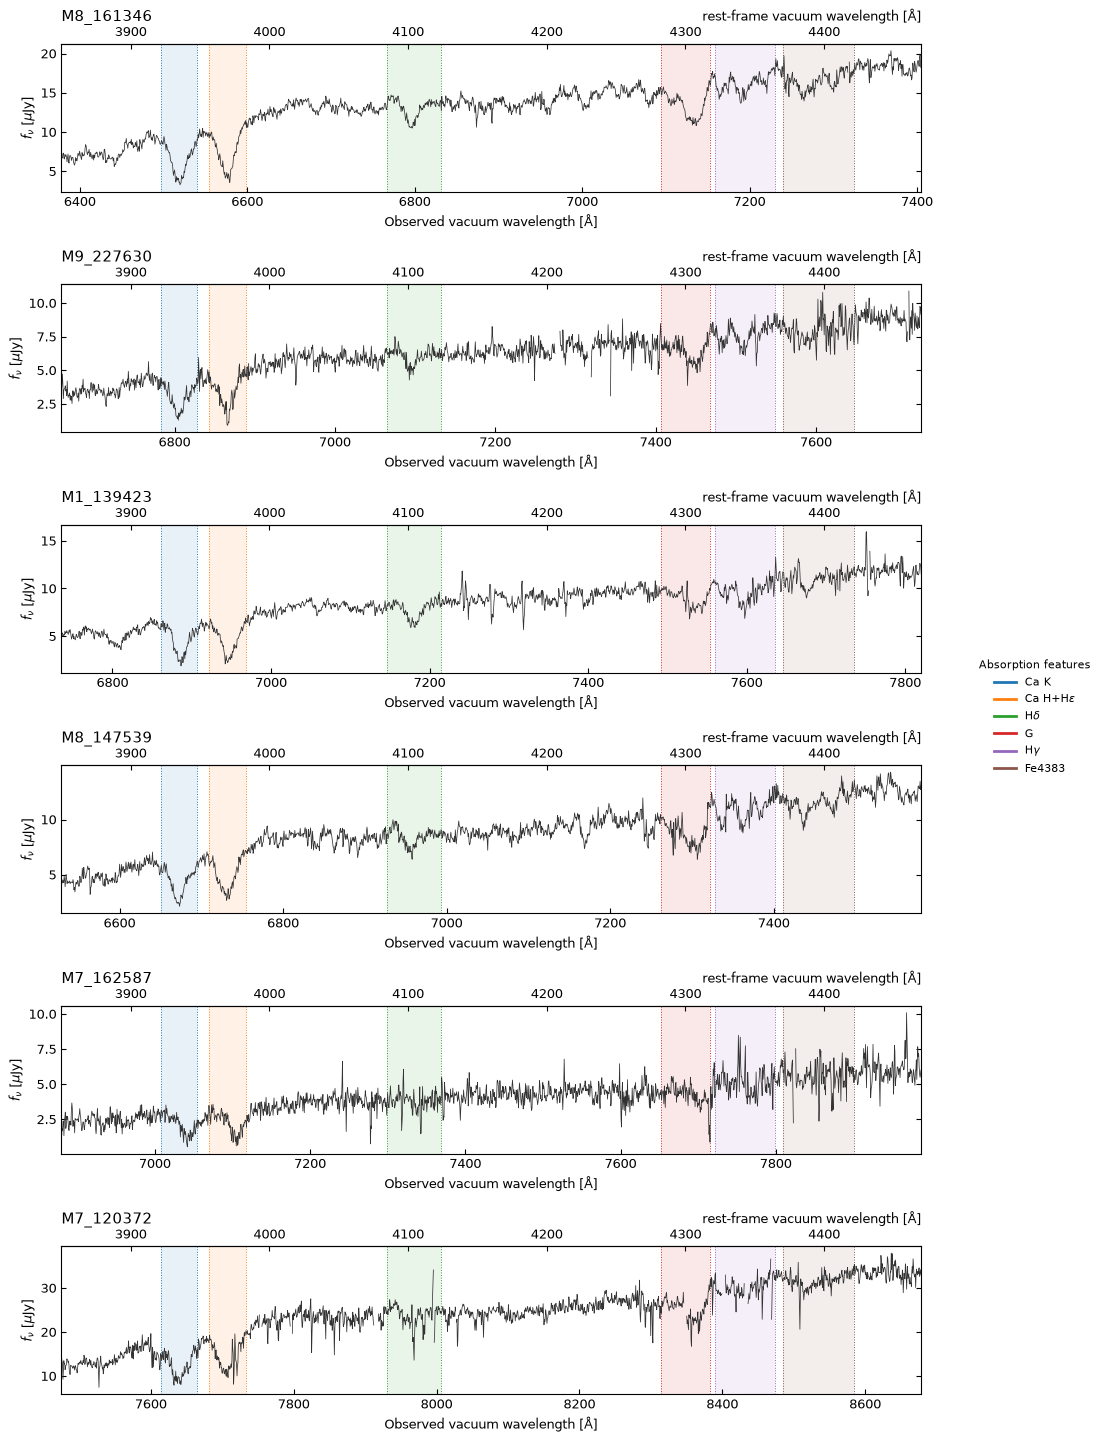

In [4]:
fig, axes = plt.subplots(6, 1, figsize=(9.5, 14.5))
for ax, spect_id in zip(axes, TEST_IDS, strict=True):
    wave, flux, good = raw_spectra[spect_id]
    z = float(test_set.loc[spect_id, "z"])
    window = (wave / (1 + z) >= 3850) & (wave / (1 + z) <= 4470)
    shown = np.where(good & window, flux, np.nan)
    ax.plot(wave, shown, color="0.2", lw=0.55)
    ax.set(xlim=(3850 * (1 + z), 4470 * (1 + z)),
           ylabel=r"$f_\nu$ [$\mu\mathrm{Jy}$]", xlabel=r"Observed vacuum wavelength [$\mathrm{\AA}$]")
    mark_rest_wavelength_axis(ax, z, title=spect_id)
    mark_absorption_features(ax, z, show_labels=(spect_id == TEST_IDS[-1]))
spectral_tight_layout(fig, h_pad=1.6)
plt.show()

- Saved spectrum and photometry images were inspected without refitting.
- M8_161346: clear metal absorption; larger optical than infrared pulls.
- M9_227630: ordinary continuum and dispersion; weak catalogue Hγ emission.
- M1_139423: stronger Balmer absorption; noise rises toward red edge.
- M8_147539: Hβ emission is marginal; Hγ emission is significant.
- M7_162587: noisier absorption spectrum; Fe4383 strength remains uncertain.
- M7_120372: Hβ is outside coverage; optical/infrared photometric pulls differ.
- Missing oxygen-line entries do not establish absence of emission.
- Existing masks exclude Hβ wherever its band is covered.
- M1_139423: the telluric mask removes 58% of the Hγ band.

In [5]:
links = []
for spect_id, row in test_set.iterrows():
    links.append(f'<li><b>{spect_id}</b>: <a href="../{row.saved_notebook}">saved fit notebook</a> '
                 f'(spectrum cell 16/output 0; photometry cell 14/output 1); '
                 f'<a href="../{row.raw_spectrum}">original spectrum</a></li>')
display(HTML("<ul>" + "".join(links) + "</ul>"))
# Full measurements, uncertainties, coverage and input paths remain machine-readable.
test_set.attrs["selected_on"] = "2026-09-22"
test_set.attrs["purpose"] = "diagnostic coverage; not statistical representativeness"
test_set.attrs["reference_excluded"] = "M1_210210"
test_set.attrs["parent_manifest"] = "results/dr2-quiescent-new-defaults/targets.json"
test_set.attrs["selection_function"] = "scripts/run_ceridwen_vast_multi_gpu.py:build_target_manifest"
test_set.attrs["catalogue_column_reference"] = "data/raw/legac_dr2/VizieR_ReadMe.txt"
test_set.attrs["photometry_reference"] = "notebooks/ceridwen_integrated_photometry_spectra.ipynb:Observations"
print(TEST_IDS)
# Embedded snapshot preserves every measured value when raw files are unavailable.
display({"application/json": {"metadata": test_set.attrs, "table": json.loads(test_set.to_json(orient="table"))}}, raw=True)

('M8_161346', 'M9_227630', 'M1_139423', 'M8_147539', 'M7_162587', 'M7_120372')
